# 6.4 Common principal components â€” Figure 3
Compare empirical cross-PC covariance with the diagonal-PC approximation, using the same fitted zero-lag PCA loading matrix. Both curves are recomputed from the model archive.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/models").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.common import core
MODEL_DIR = ROOT / "results/analysis/model_fit"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
payload = core.load_pickle_cross_platform(MODEL_DIR / "models.pkl")

,period_s
0,0.01
1,0.03
2,0.06
3,0.10
4,0.30
5,0.60
6,1.00
7,3.00
8,6.00


Correlation array shapes: (51, 9) (51, 9)


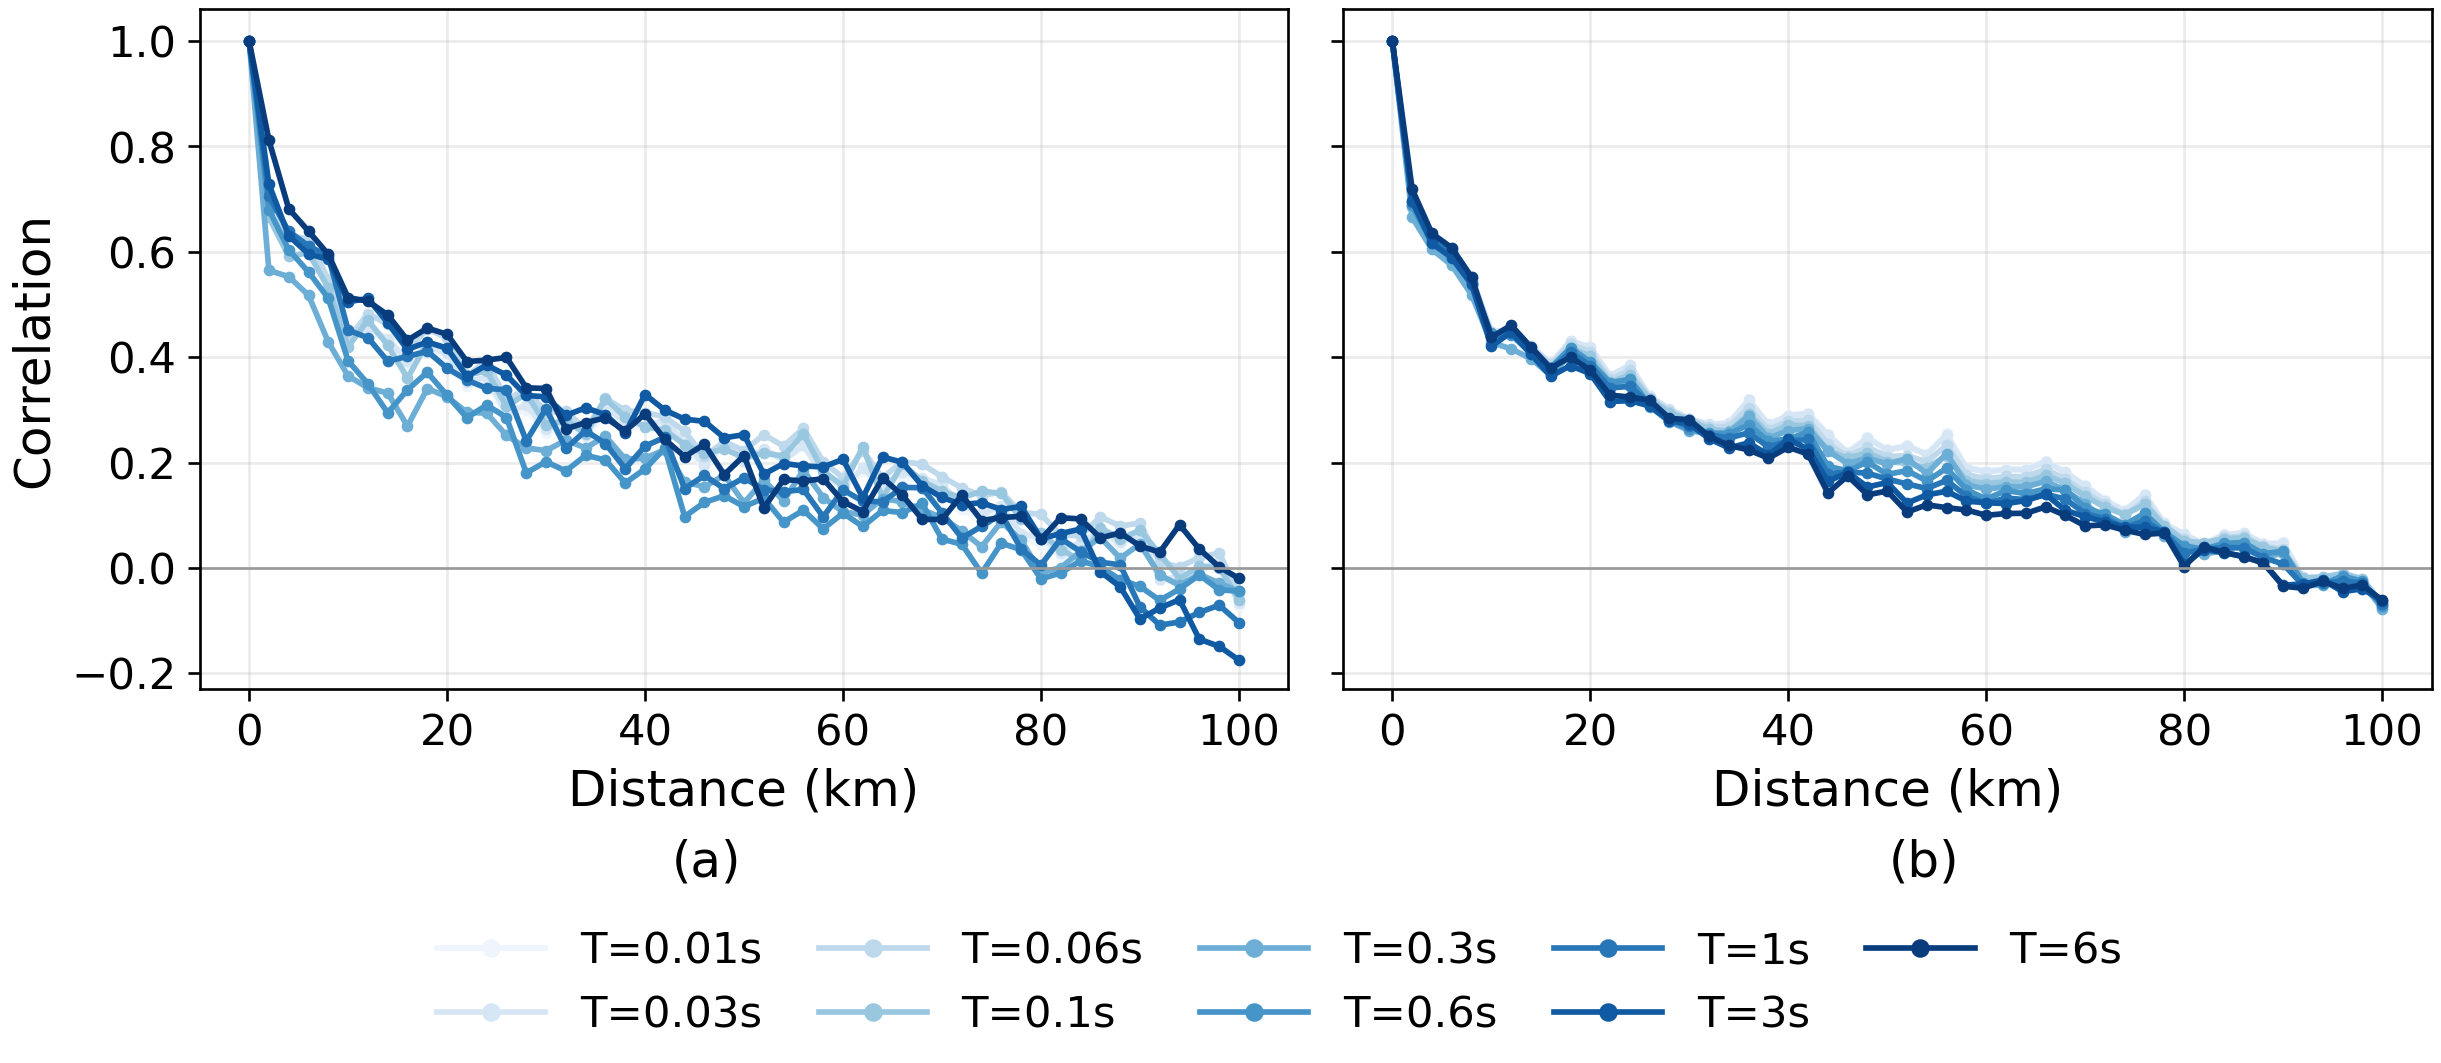

In [2]:
from scripts.common import plotting as p
periods, distance, rho_non_cpc, rho_cpc = p._direct_pc_semivariogram_correlations(payload)
display(pd.DataFrame({"period_s": periods}))
print("Correlation array shapes:", np.shape(rho_non_cpc), np.shape(rho_cpc))
fig = p.build_empirical_semivariogram_figure(payload, plt.cm.Blues(np.linspace(.05, .95, len(periods))))
fig.savefig(FIGURES / "fig03_pca_cpc.png", dpi=240, bbox_inches="tight", pad_inches=.04)
display(Image(filename=str(FIGURES / "fig03_pca_cpc.png")))
plt.close(fig)